# Encoder-Decoder Comparison: With vs Without Attention

This notebook implements and compares two sequence-to-sequence models:
1. Encoder-Decoder without attention
2. Encoder-Decoder with attention

Task: reverse a sequence of digits.

In [1]:
# Run this only if packages are missing.
# %pip install torch numpy matplotlib

In [2]:
import random
import time
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 1) Prepare Dataset and Vocabulary

Synthetic task:
- Input: random digit sequence
- Output: reversed sequence

In [3]:
DIGITS = [str(i) for i in range(10)]
stoi = {"<pad>": 0, "<sos>": 1, "<eos>": 2}
for d in DIGITS:
    stoi[d] = len(stoi)
itos = {idx: token for token, idx in stoi.items()}

PAD_IDX = stoi["<pad>"]
SOS_IDX = stoi["<sos>"]
EOS_IDX = stoi["<eos>"]
VOCAB_SIZE = len(stoi)

def generate_sequence(min_len=3, max_len=10):
    length = random.randint(min_len, max_len)
    src_tokens = [str(random.randint(0, 9)) for _ in range(length)]
    tgt_tokens = list(reversed(src_tokens))
    return src_tokens, tgt_tokens

def encode_tokens(tokens, add_sos=False, add_eos=True):
    ids = []
    if add_sos:
        ids.append(SOS_IDX)
    ids.extend(stoi[t] for t in tokens)
    if add_eos:
        ids.append(EOS_IDX)
    return ids

def decode_ids(ids):
    tokens = []
    for idx in ids:
        token = itos.get(int(idx), "<unk>")
        if token == "<eos>":
            break
        if token not in ("<sos>", "<pad>"):
            tokens.append(token)
    return tokens

def build_pairs(n_samples):
    pairs = []
    for _ in range(n_samples):
        src_tokens, tgt_tokens = generate_sequence()
        src_ids = encode_tokens(src_tokens, add_sos=False, add_eos=True)
        tgt_ids = encode_tokens(tgt_tokens, add_sos=True, add_eos=True)
        pairs.append((src_ids, tgt_ids, src_tokens, tgt_tokens))
    return pairs

train_pairs = build_pairs(4000)
val_pairs = build_pairs(600)
test_pairs = build_pairs(600)

print("Vocabulary size:", VOCAB_SIZE)
print("Train samples:", len(train_pairs))
print("Validation samples:", len(val_pairs))
print("Test samples:", len(test_pairs))
print("Sample pair:", train_pairs[0][2], "->", train_pairs[0][3])

Vocabulary size: 13
Train samples: 4000
Validation samples: 600
Test samples: 600
Sample pair: ['0', '4', '3', '3'] -> ['3', '3', '4', '0']


In [4]:
class SeqDataset(Dataset):
    def __init__(self, pairs):
        self.pairs = pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        src_ids, tgt_ids, src_tokens, tgt_tokens = self.pairs[idx]
        return (
            torch.tensor(src_ids, dtype=torch.long),
            torch.tensor(tgt_ids, dtype=torch.long),
            src_tokens,
            tgt_tokens,
        )

def collate_batch(batch):
    src_seqs, tgt_seqs, src_tokens, tgt_tokens = zip(*batch)
    src_lens = torch.tensor([len(x) for x in src_seqs], dtype=torch.long)
    tgt_lens = torch.tensor([len(x) for x in tgt_seqs], dtype=torch.long)

    src_padded = nn.utils.rnn.pad_sequence(
        src_seqs, batch_first=True, padding_value=PAD_IDX
    )
    tgt_padded = nn.utils.rnn.pad_sequence(
        tgt_seqs, batch_first=True, padding_value=PAD_IDX
    )
    return src_padded, tgt_padded, src_lens, tgt_lens, src_tokens, tgt_tokens

BATCH_SIZE = 64

train_loader = DataLoader(
    SeqDataset(train_pairs), batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_batch
)
val_loader = DataLoader(
    SeqDataset(val_pairs), batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch
)
test_loader = DataLoader(
    SeqDataset(test_pairs), batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch
)

print("DataLoaders prepared.")

DataLoaders prepared.


## 2) Define Models

The encoder is shared. Two decoder variants are implemented:
- Decoder without attention
- Decoder with Bahdanau attention

In [5]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hid_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_IDX)
        self.gru = nn.GRU(emb_dim, hid_dim, batch_first=True)

    def forward(self, src):
        embedded = self.embedding(src)
        outputs, hidden = self.gru(embedded)
        return outputs, hidden

class DecoderNoAttention(nn.Module):
    def __init__(self, vocab_size, emb_dim, hid_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_IDX)
        self.gru = nn.GRU(emb_dim, hid_dim, batch_first=True)
        self.fc_out = nn.Linear(hid_dim, vocab_size)

    def forward(self, input_token, hidden):
        embedded = self.embedding(input_token).unsqueeze(1)
        output, hidden = self.gru(embedded, hidden)
        logits = self.fc_out(output.squeeze(1))
        return logits, hidden

class Seq2SeqNoAttention(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, tgt=None, teacher_forcing=0.5, max_len=None):
        _, hidden = self.encoder(src)
        batch_size = src.size(0)
        input_token = torch.full((batch_size,), SOS_IDX, dtype=torch.long, device=src.device)

        if max_len is None:
            max_len = (tgt.size(1) - 1) if tgt is not None else src.size(1) + 3

        outputs = []
        for t in range(max_len):
            logits, hidden = self.decoder(input_token, hidden)
            outputs.append(logits.unsqueeze(1))
            predicted = logits.argmax(dim=1)

            if tgt is not None and (t + 1) < tgt.size(1) and random.random() < teacher_forcing:
                input_token = tgt[:, t + 1]
            else:
                input_token = predicted

        return torch.cat(outputs, dim=1)

In [6]:
class BahdanauAttention(nn.Module):
    def __init__(self, hid_dim):
        super().__init__()
        self.attn = nn.Linear(hid_dim * 2, hid_dim)
        self.v = nn.Linear(hid_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs, src_mask):
        batch_size, src_len, _ = encoder_outputs.shape
        hidden_last = hidden[-1].unsqueeze(1).repeat(1, src_len, 1)
        energy = torch.tanh(self.attn(torch.cat((hidden_last, encoder_outputs), dim=2)))
        scores = self.v(energy).squeeze(2)
        scores = scores.masked_fill(src_mask == 0, -1e9)
        attn_weights = torch.softmax(scores, dim=1)
        context = torch.bmm(attn_weights.unsqueeze(1), encoder_outputs)
        return context, attn_weights

class DecoderWithAttention(nn.Module):
    def __init__(self, vocab_size, emb_dim, hid_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_IDX)
        self.attention = BahdanauAttention(hid_dim)
        self.gru = nn.GRU(emb_dim + hid_dim, hid_dim, batch_first=True)
        self.fc_out = nn.Linear(hid_dim + hid_dim + emb_dim, vocab_size)

    def forward(self, input_token, hidden, encoder_outputs, src_mask):
        embedded = self.embedding(input_token).unsqueeze(1)
        context, attn_weights = self.attention(hidden, encoder_outputs, src_mask)
        rnn_input = torch.cat((embedded, context), dim=2)
        output, hidden = self.gru(rnn_input, hidden)
        logits = self.fc_out(
            torch.cat((output.squeeze(1), context.squeeze(1), embedded.squeeze(1)), dim=1)
        )
        return logits, hidden, attn_weights

class Seq2SeqWithAttention(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def make_src_mask(self, src):
        return (src != PAD_IDX)

    def forward(self, src, tgt=None, teacher_forcing=0.5, max_len=None):
        encoder_outputs, hidden = self.encoder(src)
        src_mask = self.make_src_mask(src)
        batch_size = src.size(0)
        input_token = torch.full((batch_size,), SOS_IDX, dtype=torch.long, device=src.device)

        if max_len is None:
            max_len = (tgt.size(1) - 1) if tgt is not None else src.size(1) + 3

        outputs = []
        for t in range(max_len):
            logits, hidden, _ = self.decoder(input_token, hidden, encoder_outputs, src_mask)
            outputs.append(logits.unsqueeze(1))
            predicted = logits.argmax(dim=1)

            if tgt is not None and (t + 1) < tgt.size(1) and random.random() < teacher_forcing:
                input_token = tgt[:, t + 1]
            else:
                input_token = predicted

        return torch.cat(outputs, dim=1)

## 3) Training and Evaluation Utilities

In [7]:
def train_epoch(model, loader, optimizer, criterion, clip=1.0, teacher_forcing=0.5):
    model.train()
    total_loss = 0.0

    for src, tgt, _, _, _, _ in loader:
        src = src.to(device)
        tgt = tgt.to(device)

        optimizer.zero_grad()
        outputs = model(src, tgt=tgt, teacher_forcing=teacher_forcing)
        target = tgt[:, 1:]

        loss = criterion(outputs.reshape(-1, outputs.size(-1)), target.reshape(-1))
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

@torch.no_grad()
def evaluate_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0.0

    for src, tgt, _, _, _, _ in loader:
        src = src.to(device)
        tgt = tgt.to(device)

        outputs = model(src, tgt=tgt, teacher_forcing=0.0)
        target = tgt[:, 1:]
        loss = criterion(outputs.reshape(-1, outputs.size(-1)), target.reshape(-1))
        total_loss += loss.item()

    return total_loss / len(loader)

@torch.no_grad()
def exact_match_accuracy(model, loader):
    model.eval()
    total = 0
    correct = 0

    for src, tgt, _, _, _, _ in loader:
        src = src.to(device)
        outputs = model(src, tgt=None, teacher_forcing=0.0)
        pred_ids = outputs.argmax(dim=-1).cpu().tolist()
        tgt_ids = tgt.tolist()

        for p, t in zip(pred_ids, tgt_ids):
            pred_tokens = decode_ids(p)
            tgt_tokens = decode_ids(t[1:])
            if pred_tokens == tgt_tokens:
                correct += 1
            total += 1

    return correct / max(total, 1)

def fit_model(model, train_loader, val_loader, epochs=12, lr=1e-3, teacher_forcing=0.5):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

    history = {"train_loss": [], "val_loss": []}
    best_val = float("inf")
    best_state = None

    for epoch in range(1, epochs + 1):
        start = time.time()
        train_loss = train_epoch(
            model, train_loader, optimizer, criterion, teacher_forcing=teacher_forcing
        )
        val_loss = evaluate_epoch(model, val_loader, criterion)
        elapsed = time.time() - start

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        print(
            f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | time={elapsed:.1f}s"
        )

    if best_state is not None:
        model.load_state_dict(best_state)

    return history

## 4) Train Baseline Model (Without Attention)

In [8]:
EMB_DIM = 64
HID_DIM = 128
EPOCHS = 12
LR = 1e-3

encoder_base = Encoder(VOCAB_SIZE, EMB_DIM, HID_DIM)
decoder_base = DecoderNoAttention(VOCAB_SIZE, EMB_DIM, HID_DIM)
baseline_model = Seq2SeqNoAttention(encoder_base, decoder_base).to(device)

print("Training baseline model (without attention)...")
history_base = fit_model(
    baseline_model, train_loader, val_loader, epochs=EPOCHS, lr=LR, teacher_forcing=0.5
)
acc_base = exact_match_accuracy(baseline_model, test_loader)
print(f"Baseline test exact-match accuracy: {acc_base:.4f}")

Training baseline model (without attention)...
Epoch 01 | train_loss=2.1797 | val_loss=1.7745 | time=2.7s
Epoch 02 | train_loss=1.5707 | val_loss=1.4747 | time=1.8s
Epoch 03 | train_loss=1.3139 | val_loss=1.3067 | time=2.1s
Epoch 04 | train_loss=1.1351 | val_loss=1.1539 | time=2.1s
Epoch 05 | train_loss=0.9321 | val_loss=0.9777 | time=2.0s
Epoch 06 | train_loss=0.7876 | val_loss=0.8605 | time=2.0s
Epoch 07 | train_loss=0.6545 | val_loss=0.8014 | time=2.1s
Epoch 08 | train_loss=0.6038 | val_loss=0.6953 | time=1.9s
Epoch 09 | train_loss=0.5358 | val_loss=0.6135 | time=1.7s
Epoch 10 | train_loss=0.4737 | val_loss=0.6040 | time=1.8s
Epoch 11 | train_loss=0.4246 | val_loss=0.5243 | time=1.9s
Epoch 12 | train_loss=0.3850 | val_loss=0.5067 | time=1.9s
Baseline test exact-match accuracy: 0.5917


## 5) Train Attention Model

In [9]:
encoder_attn = Encoder(VOCAB_SIZE, EMB_DIM, HID_DIM)
decoder_attn = DecoderWithAttention(VOCAB_SIZE, EMB_DIM, HID_DIM)
attention_model = Seq2SeqWithAttention(encoder_attn, decoder_attn).to(device)

print("Training attention model...")
history_attn = fit_model(
    attention_model, train_loader, val_loader, epochs=EPOCHS, lr=LR, teacher_forcing=0.5
)
acc_attn = exact_match_accuracy(attention_model, test_loader)
print(f"Attention model test exact-match accuracy: {acc_attn:.4f}")

Training attention model...
Epoch 01 | train_loss=1.8494 | val_loss=1.2637 | time=3.8s
Epoch 02 | train_loss=0.6423 | val_loss=0.7775 | time=3.6s
Epoch 03 | train_loss=0.1878 | val_loss=0.0601 | time=3.3s
Epoch 04 | train_loss=0.0368 | val_loss=0.0758 | time=3.2s
Epoch 05 | train_loss=0.0202 | val_loss=0.0553 | time=3.2s
Epoch 06 | train_loss=0.0259 | val_loss=0.0439 | time=3.2s
Epoch 07 | train_loss=0.0074 | val_loss=0.0026 | time=3.2s
Epoch 08 | train_loss=0.0019 | val_loss=0.0017 | time=3.3s
Epoch 09 | train_loss=0.0013 | val_loss=0.0013 | time=3.6s
Epoch 10 | train_loss=0.0010 | val_loss=0.0010 | time=3.3s
Epoch 11 | train_loss=0.0008 | val_loss=0.0009 | time=3.4s
Epoch 12 | train_loss=0.0007 | val_loss=0.0007 | time=3.5s
Attention model test exact-match accuracy: 1.0000


## 6) Compare Results

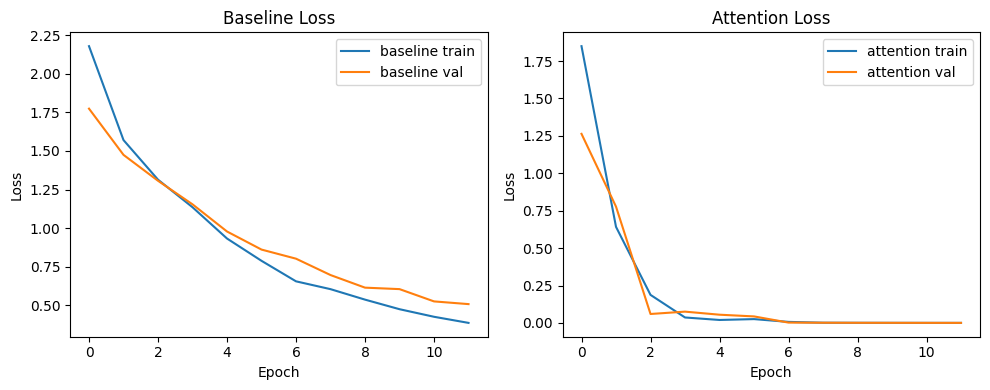

Exact-match accuracy comparison
Without attention: 0.5917
With attention   : 1.0000


In [10]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history_base["train_loss"], label="baseline train")
plt.plot(history_base["val_loss"], label="baseline val")
plt.title("Baseline Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_attn["train_loss"], label="attention train")
plt.plot(history_attn["val_loss"], label="attention val")
plt.title("Attention Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

print("Exact-match accuracy comparison")
print(f"Without attention: {acc_base:.4f}")
print(f"With attention   : {acc_attn:.4f}")

## 7) Qualitative Prediction Samples

In [11]:
@torch.no_grad()
def predict_sequence(model, src_tokens):
    model.eval()
    src_ids = encode_tokens(src_tokens, add_sos=False, add_eos=True)
    src_tensor = torch.tensor(src_ids, dtype=torch.long).unsqueeze(0).to(device)
    outputs = model(src_tensor, tgt=None, teacher_forcing=0.0, max_len=len(src_ids) + 3)
    pred_ids = outputs.argmax(dim=-1).squeeze(0).cpu().tolist()
    return decode_ids(pred_ids)

print("Sample predictions on test-like sequences:")
for _ in range(8):
    src_tokens, tgt_tokens = generate_sequence(min_len=5, max_len=10)
    pred_base = predict_sequence(baseline_model, src_tokens)
    pred_attn = predict_sequence(attention_model, src_tokens)

    print("-" * 70)
    print("Input         :", " ".join(src_tokens))
    print("Target        :", " ".join(tgt_tokens))
    print("No attention  :", " ".join(pred_base))
    print("With attention:", " ".join(pred_attn))

Sample predictions on test-like sequences:
----------------------------------------------------------------------
Input         : 0 1 9 8 0 1 1 0 6 3
Target        : 3 6 0 1 1 0 8 9 1 0
No attention  : 3 6 0 1 1 8 0 1 0 9
With attention: 3 6 0 1 1 0 8 9 1 0
----------------------------------------------------------------------
Input         : 2 2 4 4 3 2 6 5 4
Target        : 4 5 6 2 3 4 4 2 2
No attention  : 4 4 6 5 3 2 2 4 2 2
With attention: 4 5 6 6 2 3 4 4 2 2
----------------------------------------------------------------------
Input         : 5 1 8 9 8 1 9 7 8
Target        : 8 7 9 1 8 9 8 1 5
No attention  : 8 7 9 8 1 1 8 8 5 1
With attention: 8 7 7 9 1 8 9 8 1 5
----------------------------------------------------------------------
Input         : 5 5 1 7 9 1 5 4 3 6
Target        : 6 3 4 5 1 9 7 1 5 5
No attention  : 6 3 4 1 5 1 9 1 5 5
With attention: 6 3 4 5 1 9 7 1 5 5
----------------------------------------------------------------------
Input         : 8 0 3 4 5 9 4 8 9


## 8) Conclusion

After execution, summarize:
- Which model achieved better exact-match accuracy
- Which model converged faster
- Typical failure patterns of the baseline model